In [30]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [31]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from elbow_method import elbow, elbow_k, elbow_KMeans
from cluster_analize import get_dispersion
from vizualize import visualize_clusters, start_visualization, visualize_core_clusters, visualize_mean_center_clusters
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin, pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.cluster import MeanShift

In [32]:
dispersions = {}

In [33]:
cluster_col = lambda method: f'{method}_Cluster'

## Імпорт даних

In [34]:
df = (pd.read_excel('../Lab5/data.xlsx', na_values='-').set_index('Country')
      .apply(pd.to_numeric, errors='coerce').fillna(0))
df

,All,Work,OrgTour,Private
Country,,,,
Албанія,4,0.0,0.0,4.0
Азербайджан,16791,0.0,0.0,16791.0
Австрія,96809,663.0,11639.0,84507.0
Вірменія,12433,158.0,1367.0,10908.0
Бельгія,17487,29.0,0.0,17458.0
...,...,...,...,...
Македонія,45,0.0,12.0,33.0
Єгипет,400427,542.0,24864.0,375021.0
Велика Британія,76590,0.0,0.0,76590.0


### Візуалізація початкових даних

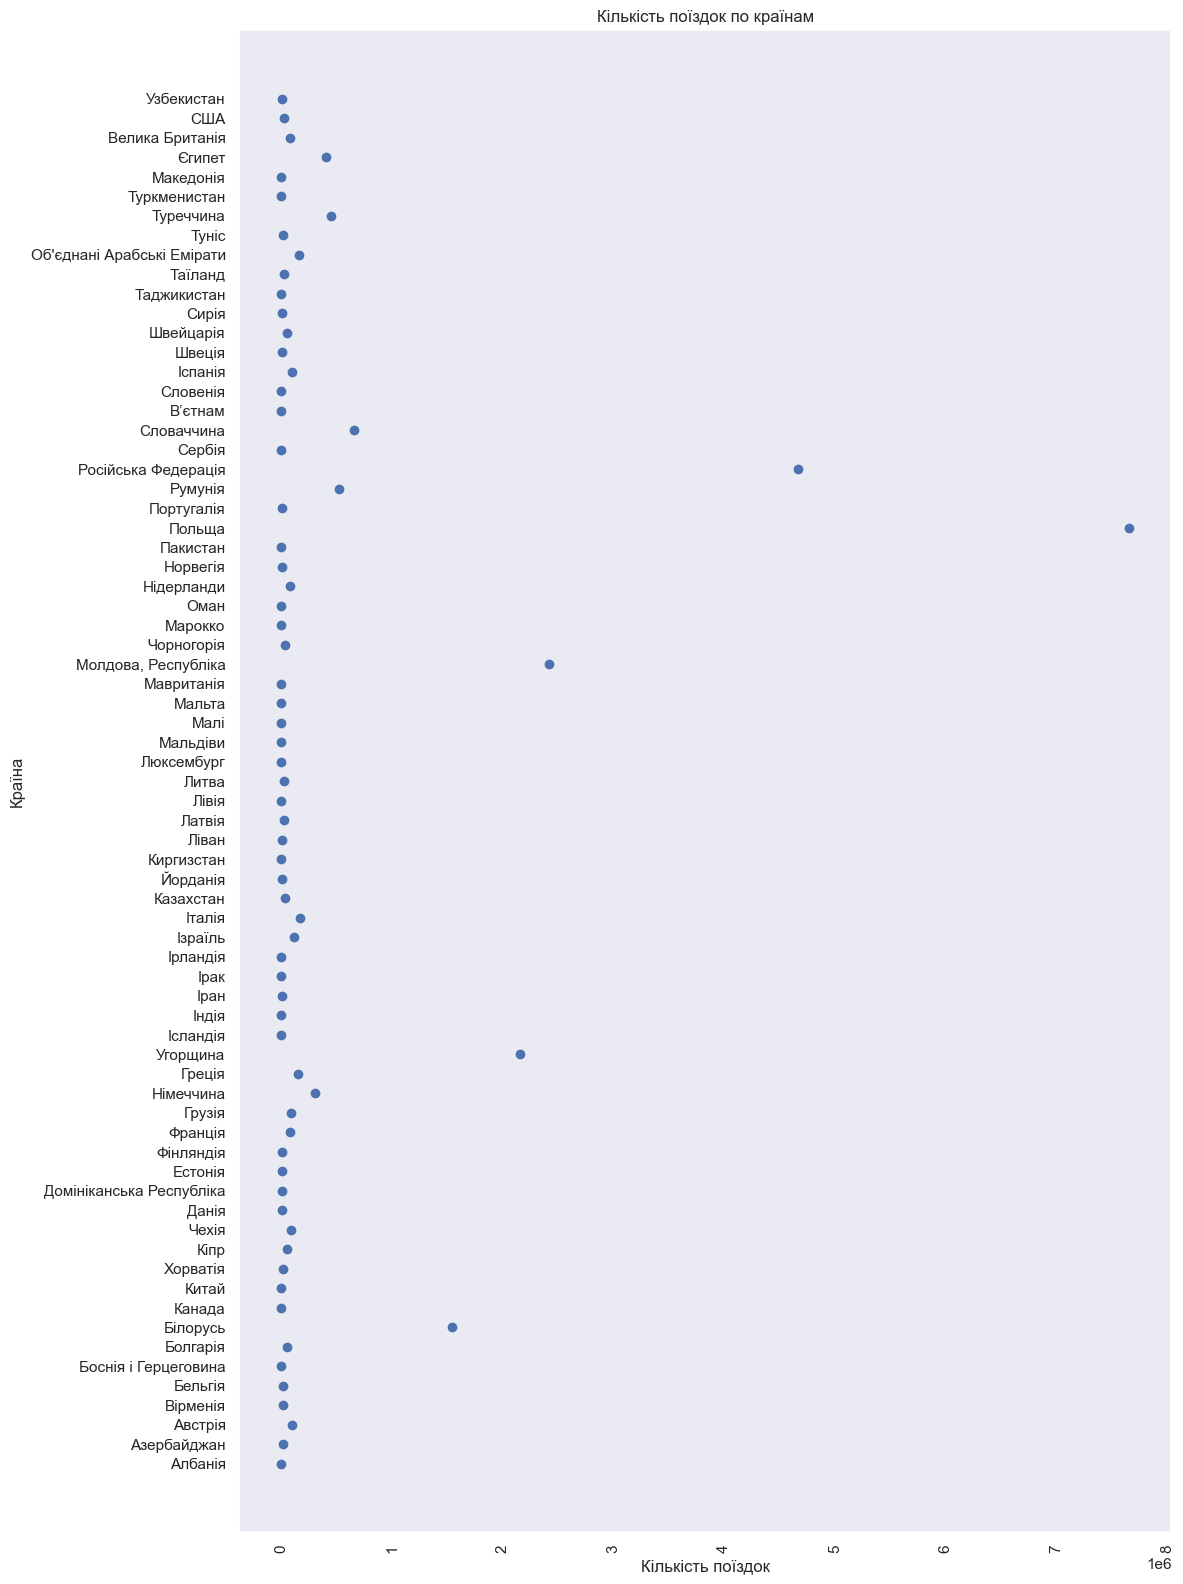

In [35]:
start_visualization(df)

### Обчмслення відстаней

In [36]:
X = df[['All']].values
Z = linkage(X, method='ward')

## Метоод перебору фіксованих відстаней

In [37]:
METHOD = 'FixedRadiusSpheres'

Поріг: 1318288.40 | k: 5, Inertia: 1222344842300.41, Зміна: 0.00%
Поріг: 2636576.80 | k: 4, Inertia: 2958689038152.82, Зміна: 142.05%
Поріг: 3954865.20 | k: 3, Inertia: 11720235104499.82, Зміна: 296.13%
Поріг: 5273153.60 | k: 2, Inertia: 34011607542161.38, Зміна: 190.20%
Поріг: 11864595.59 | k: 1, Inertia: 172922300365587.66, Зміна: 408.42%
Різниця між спадами: ['-142.05%', '-154.08%', '105.93%', '-218.23%']
Оптимальний поріг: 3954865.20, Кількість кластерів: 3


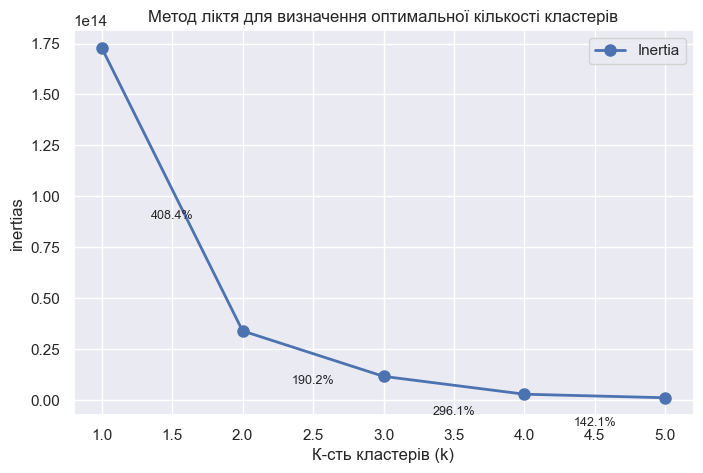

In [38]:
k, optimal_threshold = elbow(Z, df, 'distance')

### Кластеризація

In [39]:
df[cluster_col(METHOD)] = fcluster(Z, t=optimal_threshold, criterion='distance')

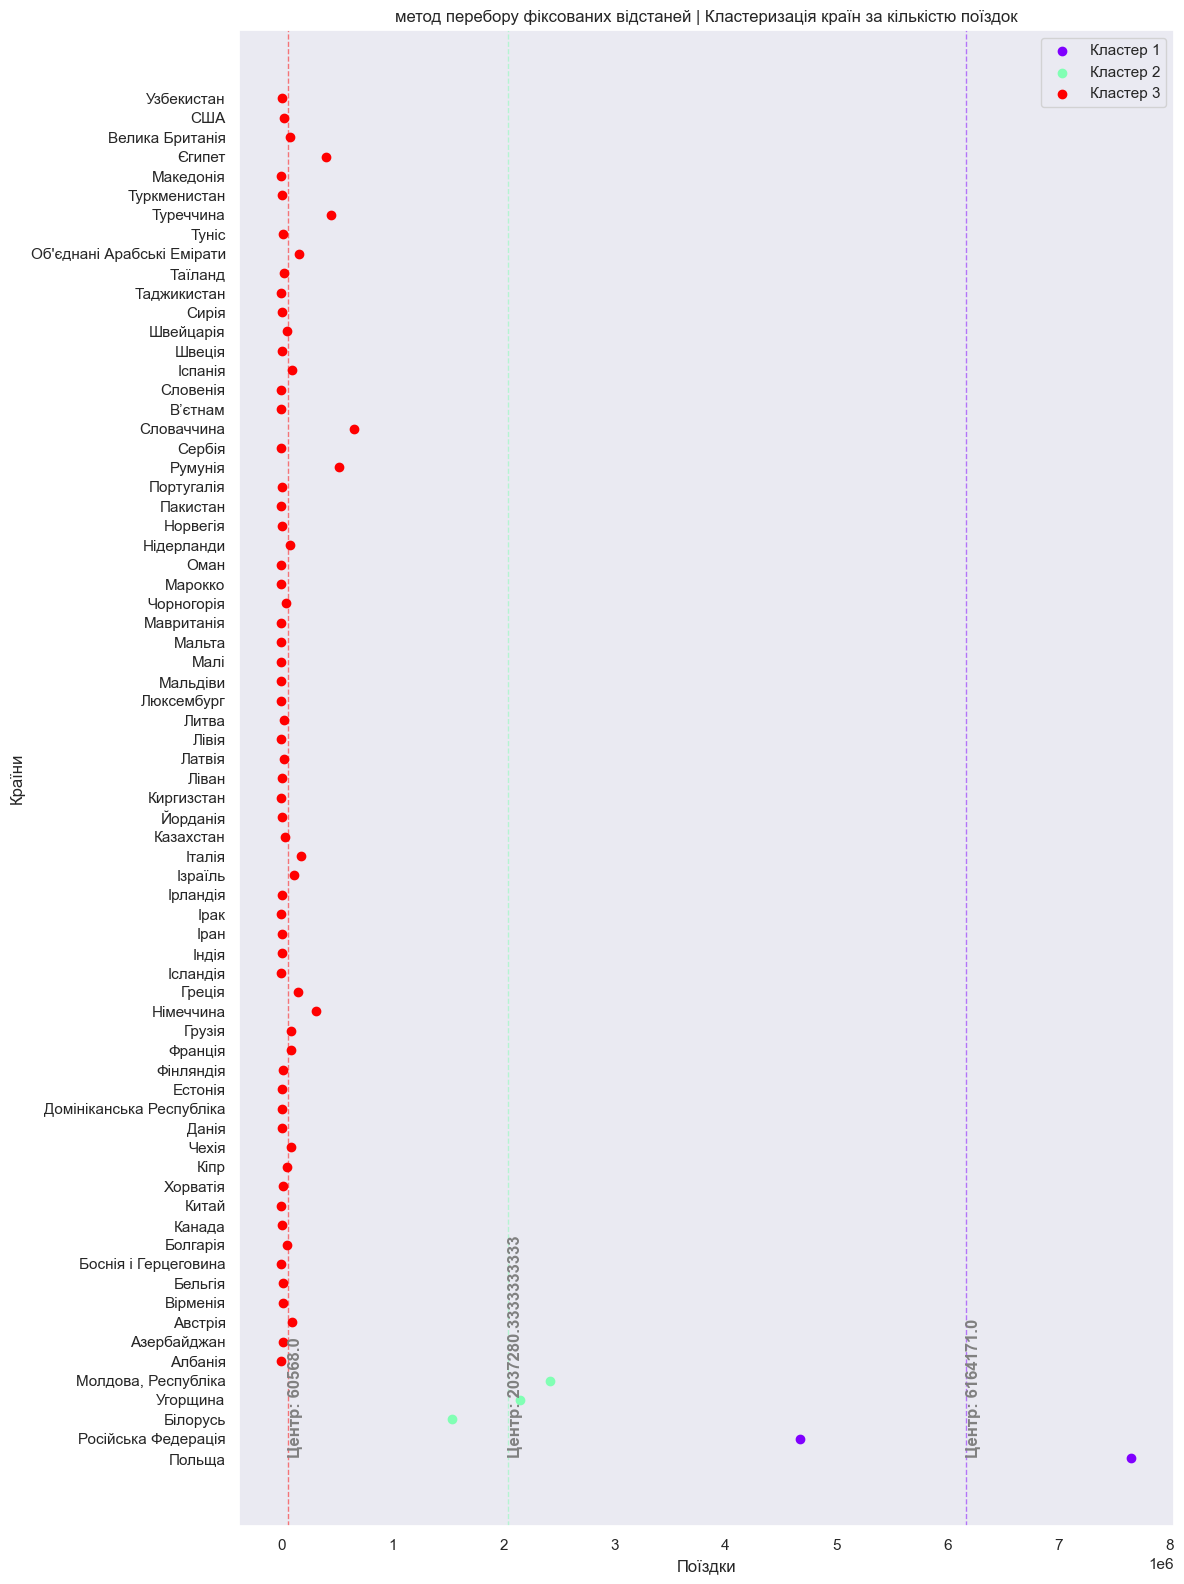

In [40]:
dispersions[METHOD] = get_dispersion(df, df[cluster_col(METHOD)])
visualize_clusters(df, dispersions[METHOD], 'метод перебору фіксованих відстаней', cluster_column=cluster_col(METHOD))

## Метод повним перебором об'єктів.

In [41]:
METHOD = 'FullEnumeration'

k: 1, Inertia: 172922300365598.03, Зміна: 0.00%
k: 2, Inertia: 34011607542164.24, Зміна: 80.33%
k: 3, Inertia: 11720235104499.82, Зміна: 65.54%
k: 4, Inertia: 2958689038152.82, Зміна: 74.76%
k: 5, Inertia: 1222344842300.41, Зміна: 58.69%
k: 6, Inertia: 431951914426.41, Зміна: 64.66%
k: 7, Inertia: 257451933377.39, Зміна: 40.40%
k: 8, Inertia: 160702123930.09, Зміна: 37.58%
k: 9, Inertia: 88796098612.09, Зміна: 44.74%
k: 10, Inertia: 59151472379.92, Зміна: 33.39%
Різниця між спадами: ['-80.33%', '14.79%', '-9.22%', '16.07%', '-5.98%', '24.26%', '2.82%', '-7.17%', '11.36%']
Оптимальна кількість кластерів: 7


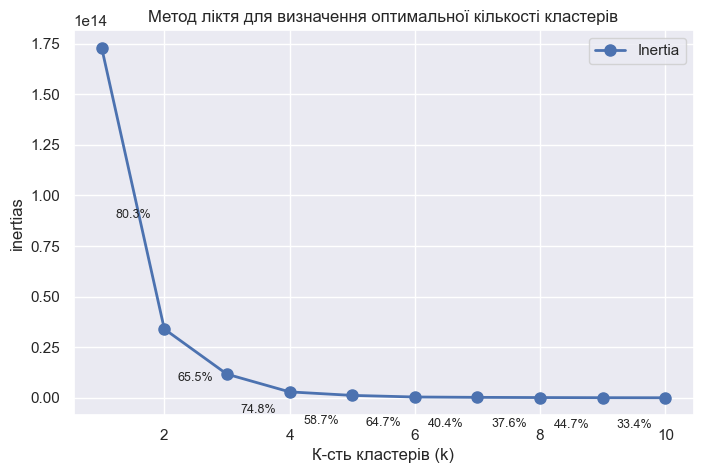

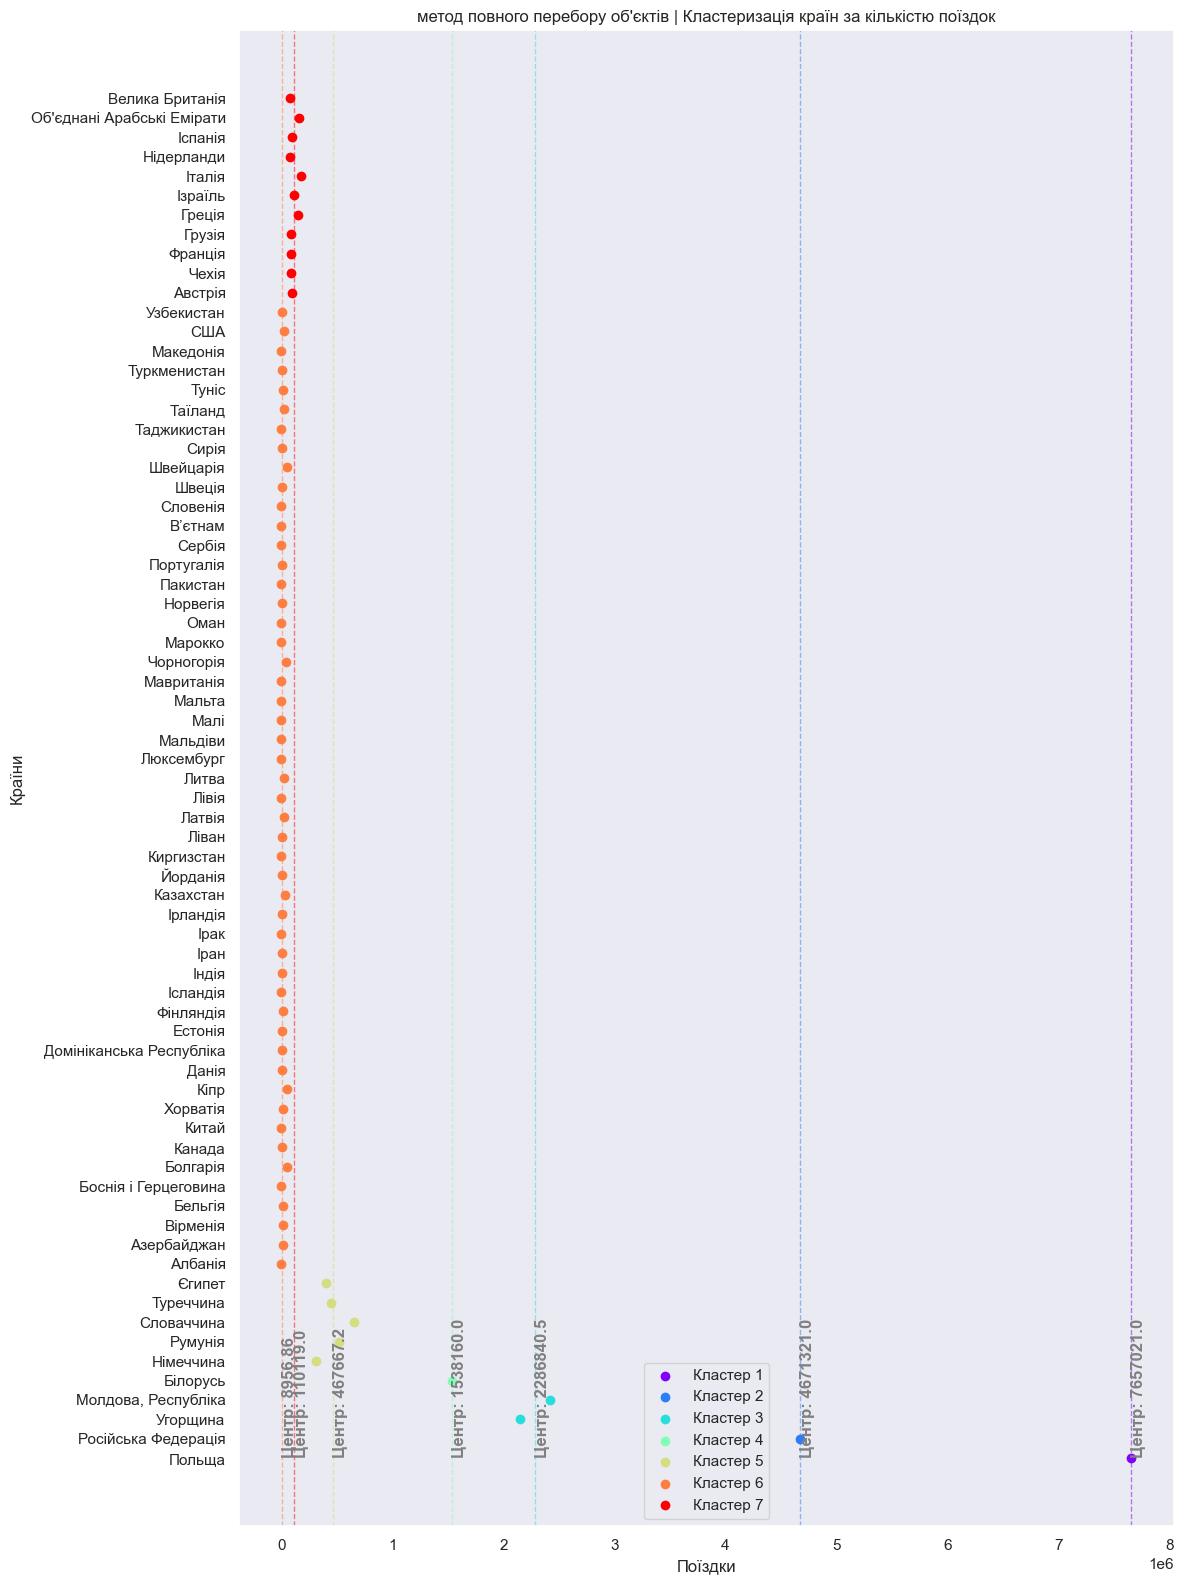

In [42]:
k = elbow_k(Z, df, 10)
df[cluster_col(METHOD)] = fcluster(Z, t=k, criterion='maxclust')
dispersions[METHOD] = get_dispersion(df, df[cluster_col(METHOD)])
visualize_clusters(df, dispersions[METHOD], 'метод повного перебору об\'єктів', cluster_column=cluster_col(METHOD))

## метод двоступінчастої кластеризації з виділенням ядра (згущення) об'єктів класифікації.

In [43]:
METHOD = 'TwoStepCoreSpheres'

In [44]:
core_threshold = 0.3

global_centroid = np.mean(X, axis=0)

distances = np.linalg.norm(X - global_centroid, axis=1)

threshold_value = np.quantile(distances, core_threshold)
core_mask = distances <= threshold_value
df['is_core'] = core_mask
X_core = X[core_mask]

In [45]:
core_data = df[df['is_core']][['All']]
k = elbow_KMeans(core_data, 10)

Різниця між спадами: ['47.71%', '1.23%', '-8.56%', '-25.98%', '48.13%', '-22.51%', '7.37%']
Оптимальна кількість кластерів: 2


In [46]:
kmeans = KMeans(n_clusters=k, random_state=42)
_ = kmeans.fit(X_core)

In [47]:
core_labels = kmeans.labels_

full_labels = np.full(X.shape[0], -1)
full_labels[core_mask] = core_labels

non_core_mask = ~core_mask
X_non_core = X[non_core_mask]
assigned_labels = pairwise_distances_argmin(X_non_core, kmeans.cluster_centers_)

full_labels[non_core_mask] = assigned_labels
df[cluster_col(METHOD)] = full_labels

In [48]:
dispersions[METHOD] = get_dispersion(df, full_labels)

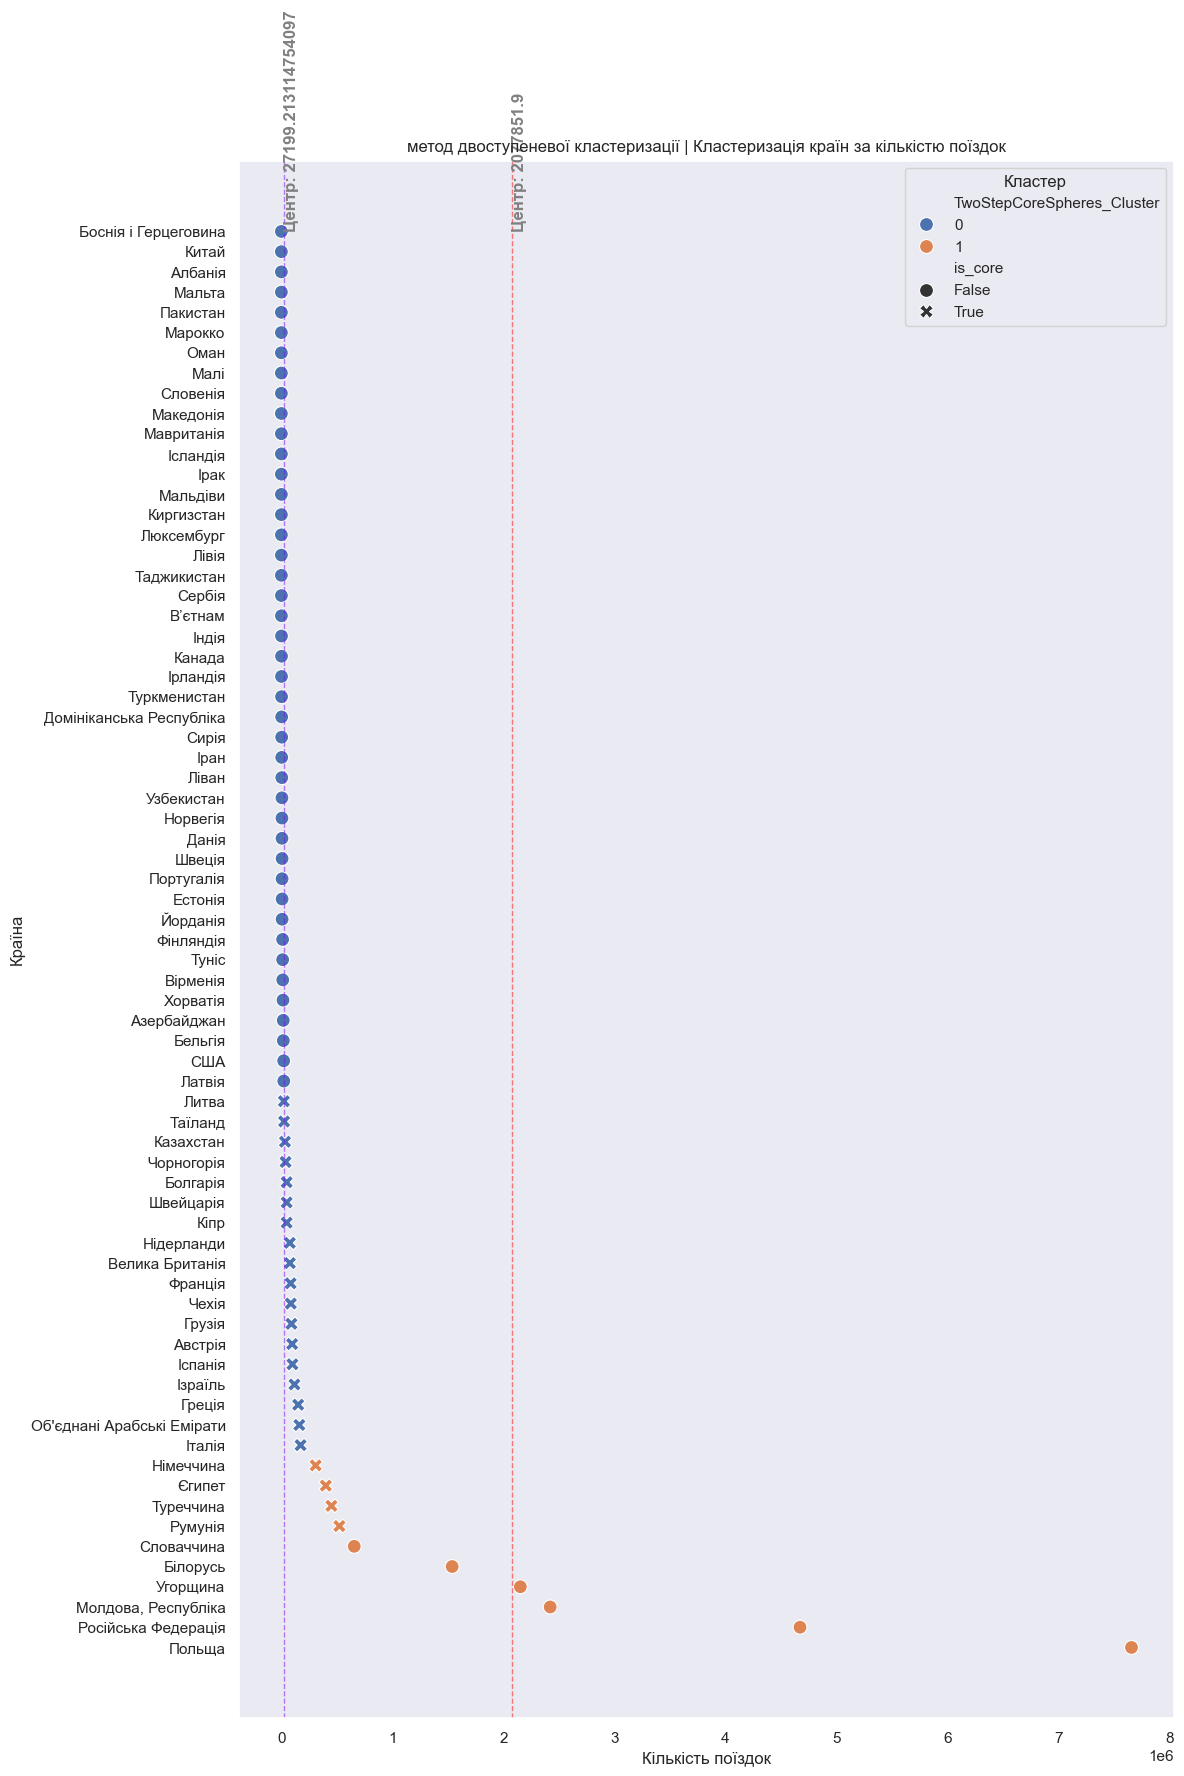

In [49]:
visualize_core_clusters(df, dispersions[METHOD], cluster_column=cluster_col(METHOD))

## Кластеризація інтегральним методом геометризації інформаційного поля

In [50]:
METHOD = 'InfoFieldGeometrization'

In [51]:
X = df[['All']].values
X_scaled = StandardScaler().fit_transform(X)

kde = KernelDensity(kernel='gaussian', bandwidth=0.8).fit(X_scaled)
densities = np.exp(kde.score_samples(X_scaled))
df['density'] = densities

meanshift = MeanShift(bandwidth=1.0).fit(X_scaled)
df[cluster_col(METHOD)] = meanshift.labels_

dispersions[METHOD] = get_dispersion(df, df[cluster_col(METHOD)])

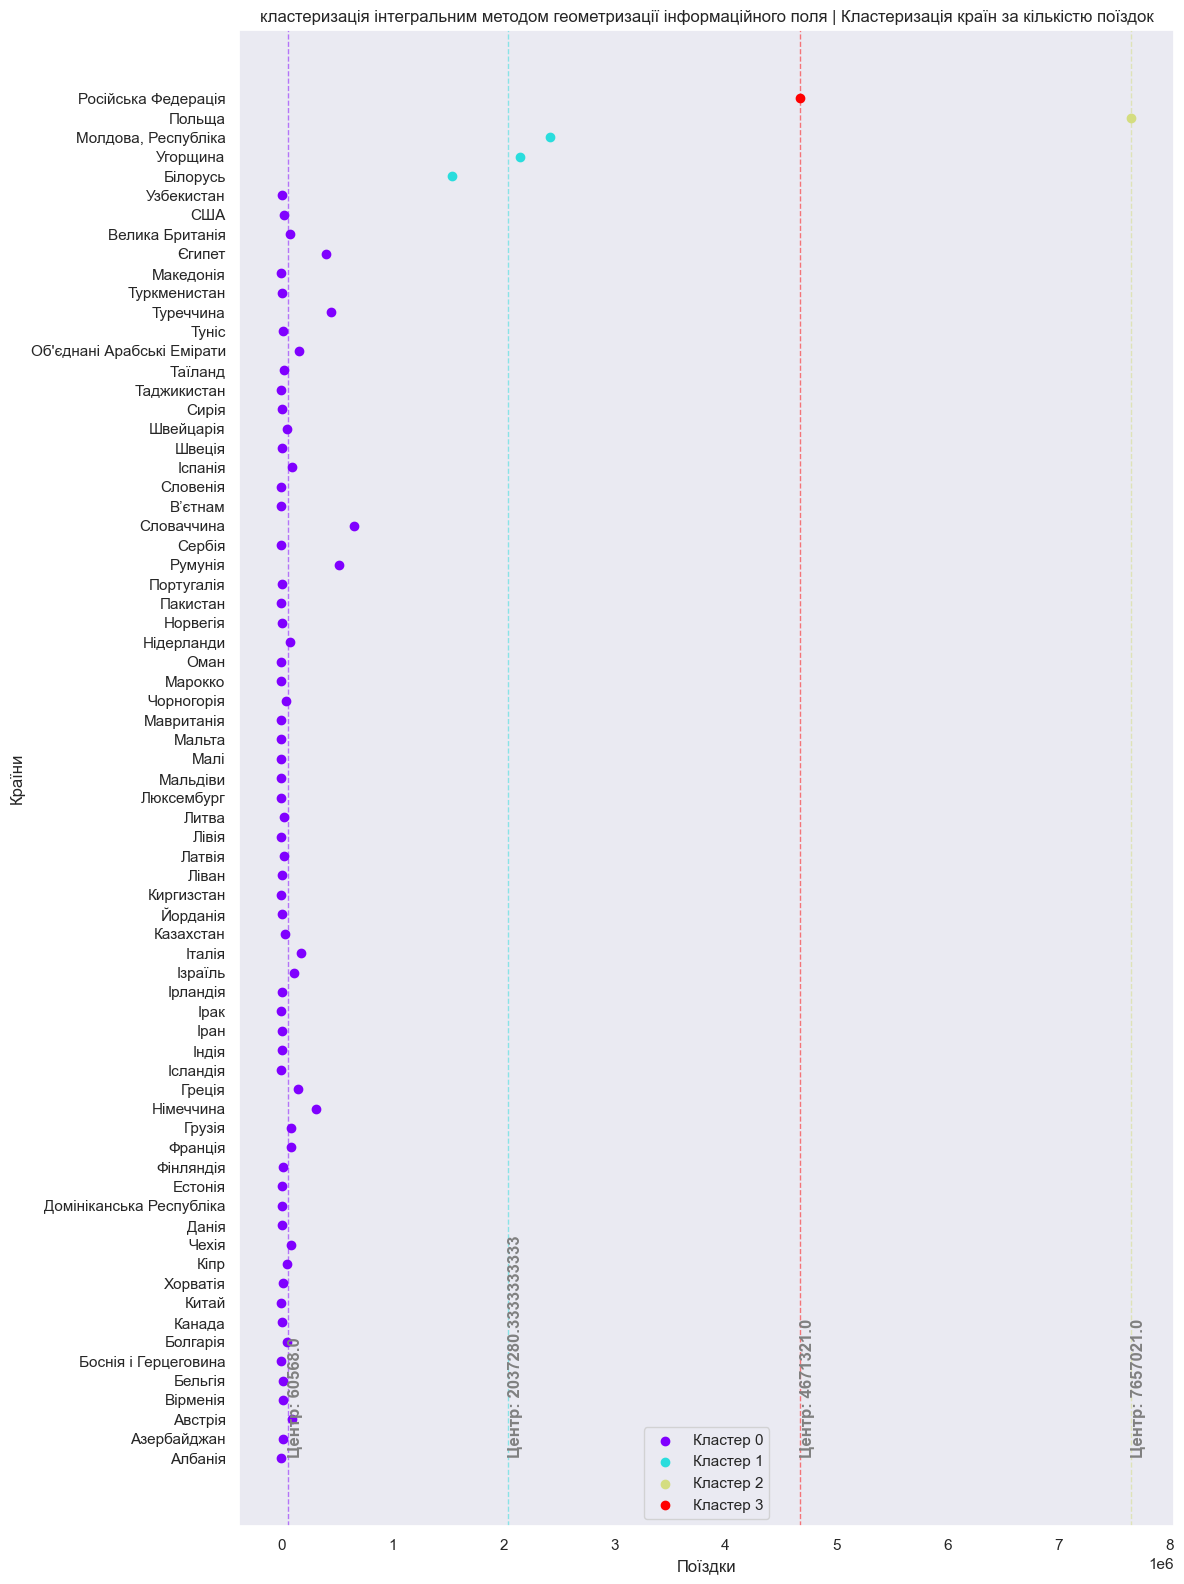

In [52]:
visualize_clusters(df, dispersions[METHOD], 'кластеризація інтегральним методом геометризації інформаційного поля',
                   cluster_column=cluster_col(METHOD))

## Кластеризація методом визначення центра кластера за допомогою обчислення середньо арифметичних відстаней між об'єктами.

In [53]:
METHOD = 'AvgDistanceCenter'

In [54]:
max_iter = 100

X = df[['All']].values
n = X.shape[0]
k = elbow_KMeans(X, 10)

Різниця між спадами: ['15.05%', '-9.62%', '14.73%', '-2.89%', '20.86%', '17.38%', '-25.05%']
Оптимальна кількість кластерів: 4


In [55]:
initial_centers_idx = np.random.choice(n, k, replace=False)
centers_idx = initial_centers_idx.copy()

for iteration in range(max_iter):
    distances_to_centers = pairwise_distances(X, X[centers_idx])
    labels = np.argmin(distances_to_centers, axis=1)

    new_centers_idx = []
    for cluster_idx in range(k):
        cluster_points_idx = np.where(labels == cluster_idx)[0]
        cluster_points = X[cluster_points_idx]

        if len(cluster_points_idx) == 0:
            continue

        dist_matrix = pairwise_distances(cluster_points)
        mean_distances = dist_matrix.mean(axis=1)

        best_idx_in_cluster = cluster_points_idx[np.argmin(mean_distances)]
        new_centers_idx.append(best_idx_in_cluster)

    if np.array_equal(centers_idx, new_centers_idx):
        break
    centers_idx = new_centers_idx

distances_to_centers = pairwise_distances(X, X[centers_idx])
labels = np.argmin(distances_to_centers, axis=1)

print(centers_idx)
df[cluster_col(METHOD)] = labels
center_names = df.index[centers_idx].tolist()
df['is_center'] = df.index.isin(center_names)

[41, 64, 12, 65]


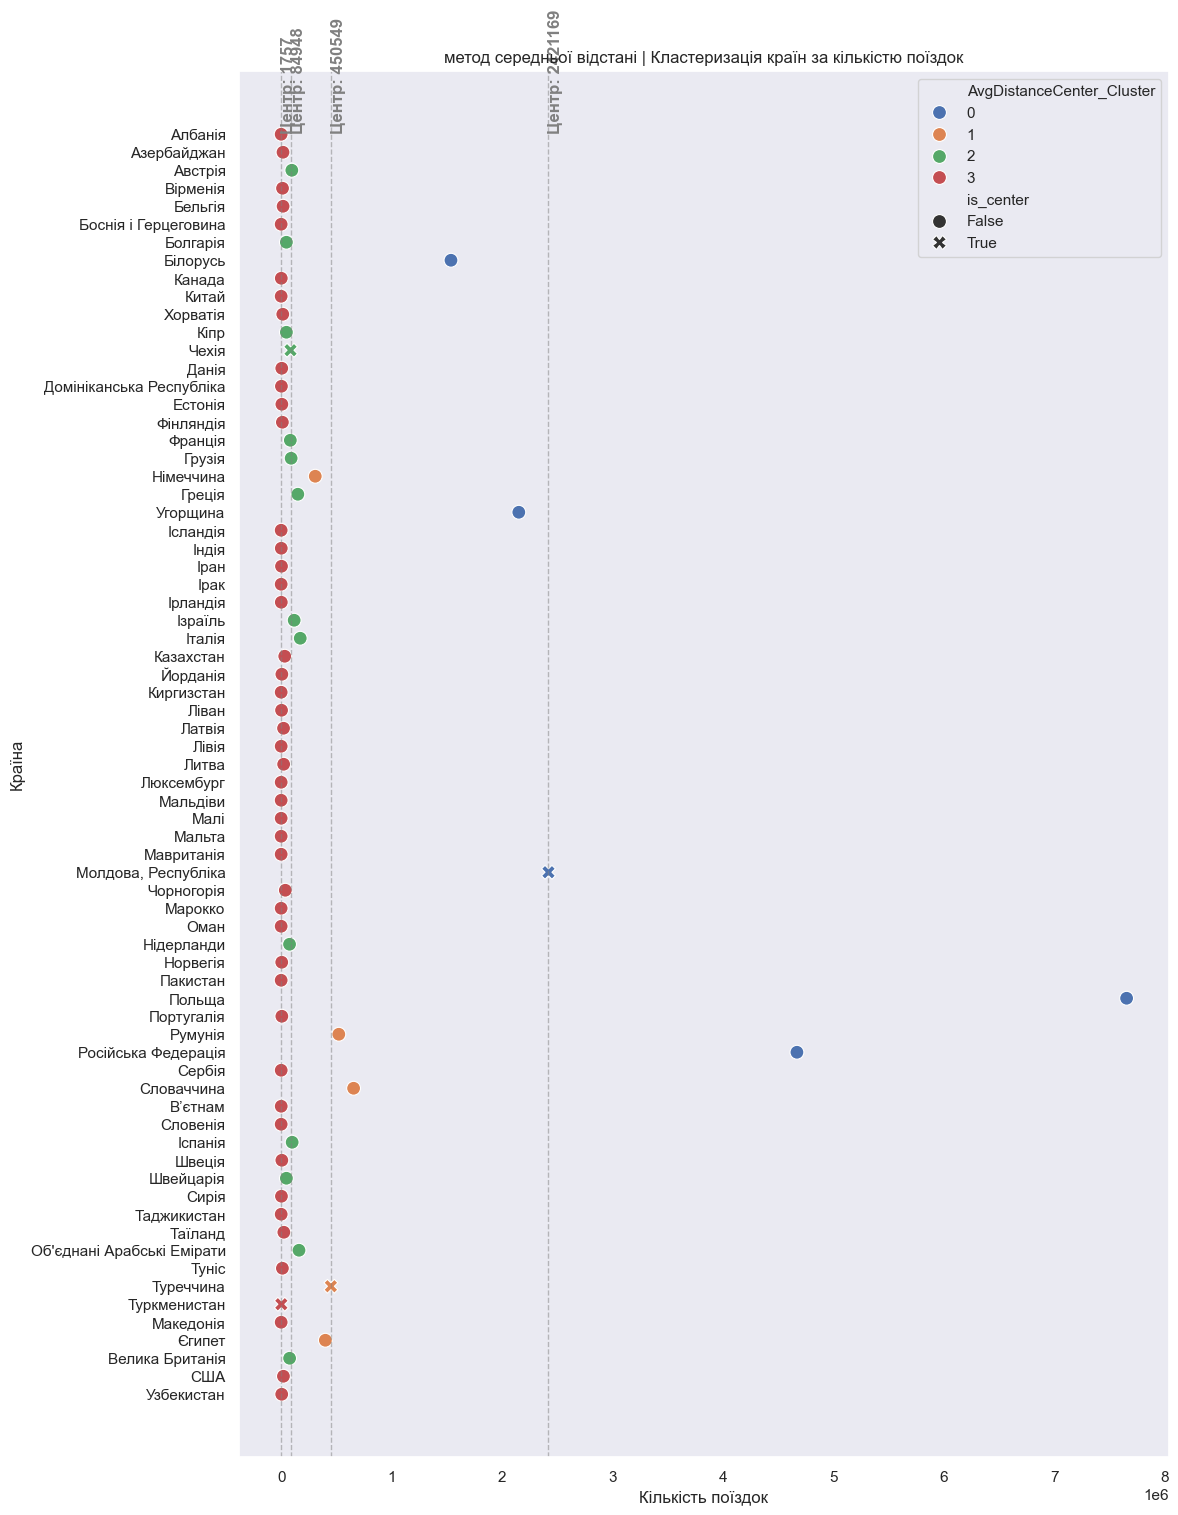

In [56]:
dispersions[METHOD] = get_dispersion(df, df[cluster_col(METHOD)])

visualize_mean_center_clusters(df, dispersions[METHOD], cluster_column=cluster_col(METHOD))

## Порівняння кластеризацій

In [57]:
summary = []

for method, dispersion_df in dispersions.items():
    total_dispersion = dispersion_df['Dispersion'].mean()
    total_size = dispersion_df['Size'].sum()
    weighted_dispersion = (
            (dispersion_df['Dispersion'] * dispersion_df['Size']).sum() / total_size
    )

    summary.append({
        'Method': method,
        'Clusters': len(dispersion_df),
        'TotalSize': total_size,
        'MeanDispersion': total_dispersion,
        'WeightedDispersion': weighted_dispersion
    })

summary_df = pd.DataFrame(summary)
summary_df

,Method,Clusters,TotalSize,MeanDispersion,WeightedDispersion
0,FixedRadiusSpheres,3,71,1.566657e+12,1.650737e+11
1,FullEnumeration,7,71,9.632108e+09,3.626084e+09
2,TwoStepCoreSpheres,2,71,5.072102e+12,1.431295e+12
3,InfoFieldGeometrization,4,71,7.979912e+10,4.167168e+10
4,AvgDistanceCenter,4,71,2.499275e+12,7.044983e+11


In [58]:
compact_method = summary_df.loc[summary_df['WeightedDispersion'].idxmin(), 'Method']
print(f"Найкомпактніший метод кластеризації: {compact_method}")

Найкомпактніший метод кластеризації: FullEnumeration
